# 2.1 Reaction-feature geometry of Ru-AHK source domains

This notebook provides a direct geometric analysis of the reaction
representations used in notebooks **1.3** and **1.4**.

The analysis is organized in two stages:

1. compare the mechanism-aligned and mechanism-mismatched Ru-AHK sources with
   the Ru-AHO target;
2. extend the same PCA and distance analysis to all Ru-AHK,
   substrate-similar, ligand-similar, and reaction-representation-matched
   sources.

The reaction-representation-matched source is not reselected here. Notebook
2.1 reads the exact fold-local membership manifests generated in notebooks 1.3
and 1.4. The quantitative distance analysis is performed in the same
fold-local, median-imputed and standardized complete reaction representation
used for RBF-MMD matching. Consequently, the RBF-MMD value shown here is the
exact prespecified matching criterion.

PCA is used only for two-dimensional visualization. RBF-MMD is the primary
matching metric; energy distance, sliced Wasserstein distance, and symmetric
kNN distance are reported as cross-metric sensitivities.

All figures are displayed in the notebook and saved under:

`results/2_1_reaction_feature_geometry/`


In [1]:
from __future__ import annotations

from collections import OrderedDict
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
N_FOLDS = 5
DIRECT_PCA_DIM = 64
KNN_K = 10
MAX_DISTANCE_POINTS = 800
RBF_MMD_GAMMA_MAX_POINTS = 1000
SLICED_PROJECTIONS = 128
SLICED_QUANTILES = 256

DATASET_ORDER = [
    "all_ru_ahk",
    "ru_ahk_inner",
    "ru_ahk_outer",
    "ru_aho_inner",
]

SOURCE_RULE_ORDER = [
    "mechanism_aligned",
    "mechanism_mismatched",
    "all_ru_ahk",
    "substrate_similar",
    "ligand_similar",
    "reaction_representation_matched",
]

MECHANISM_RULES = [
    "mechanism_aligned",
    "mechanism_mismatched",
]

EXTENDED_RULES = [
    "all_ru_ahk",
    "substrate_similar",
    "ligand_similar",
    "reaction_representation_matched",
]

RULE_LABELS = {
    "mechanism_aligned": "Mechanism aligned",
    "mechanism_mismatched": "Mechanism mismatched",
    "all_ru_ahk": "All Ru-AHK",
    "substrate_similar": "Substrate similar",
    "ligand_similar": "Ligand similar",
    "reaction_representation_matched": "Reaction-representation matched",
}

# Main-text palette: target = green, aligned = blue, mismatched = orange.
# Extended source-domain rules use distinct auxiliary colors.
TARGET_COLOR = "#009E73"
RULE_COLORS = {
    "mechanism_aligned": "#0072B2",
    "mechanism_mismatched": "#D55E00",
    "all_ru_ahk": "#7B61A8",
    "substrate_similar": "#CC79A7",
    "ligand_similar": "#8C564B",
    "reaction_representation_matched": "#7F7F7F",
}

DESCRIPTOR_LABELS = {
    "maccs": "MACCS",
    "spoc": "SPOC",
}

METRIC_LABELS = OrderedDict(
    [
        ("rbf_mmd", "RBF-MMD"),
        ("energy_distance", "Energy distance"),
        ("sliced_wasserstein", "Sliced Wasserstein"),
        ("symmetric_knn_distance", "Symmetric kNN distance"),
    ]
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "data" / "transfer").exists()
            and (candidate / "data" / "all_ahk_Ru").exists()
        ):
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
ALL_AHK_DIR = PROJECT_ROOT / "data" / "all_ahk_Ru"

OUT_DIR = PROJECT_ROOT / "results" / "2_1_reaction_feature_geometry"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
for directory in [FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATHS = OrderedDict(
    [
        ("all_ru_ahk", ALL_AHK_DIR / "processed_ahk_dataset_Ru.csv"),
        ("ru_ahk_inner", TRANSFER_DIR / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DIR / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DIR / "ru_aho_inner.csv"),
    ]
)

ANALYSIS_INPUTS = {
    "maccs": {
        "feature_cache": (
            PROJECT_ROOT
            / "results"
            / "1_3_maccs_source_domain_extension"
            / "feature_cache"
            / "maccs_compatible_combined_feature_matrix.npy"
        ),
        "membership": (
            PROJECT_ROOT
            / "results"
            / "1_3_maccs_source_domain_extension"
            / "tables"
            / "maccs_source_selection_membership.csv"
        ),
    },
    "spoc": {
        "feature_cache": (
            PROJECT_ROOT
            / "results"
            / "1_4_spoc_source_domain_extension"
            / "feature_cache"
            / "spoc_compatible_combined_feature_matrix.npy"
        ),
        "membership": (
            PROJECT_ROOT
            / "results"
            / "1_4_spoc_source_domain_extension"
            / "tables"
            / "spoc_source_selection_membership.csv"
        ),
    },
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR.relative_to(PROJECT_ROOT)}")

Project root: /home/syz/ru-mechanism-transfer
Output directory: results/2_1_reaction_feature_geometry


## 1. Load the canonical domains, feature caches, and source manifests

The cached row order is fixed by notebooks 1.3 and 1.4:

`all Ru-AHK → Ru-AHK inner → Ru-AHK outer → Ru-AHO inner`.

The membership tables preserve the exact fold-local source rows used in the
transfer benchmark. The reaction-representation control must carry the locked
variant identifier:

`reaction_repr_rbf_mmd_minimized`.

In [2]:
def load_table(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    table = pd.read_csv(path).reset_index(drop=True)
    if "ddG" not in table.columns:
        raise KeyError(f"{label} is missing the ddG column.")
    return table


DATASETS = OrderedDict(
    (key, load_table(path, key))
    for key, path in DATA_PATHS.items()
)

DATA_SUMMARY = pd.DataFrame(
    [
        {
            "dataset_key": key,
            "n_rows": len(table),
            "n_substrates": (
                table["Reactant SMILES"].nunique()
                if "Reactant SMILES" in table.columns
                else np.nan
            ),
            "n_ligands": (
                table["Ligand SMILES"].nunique()
                if "Ligand SMILES" in table.columns
                else np.nan
            ),
        }
        for key, table in DATASETS.items()
    ]
)
display(DATA_SUMMARY)

EXPECTED_TOTAL_ROWS = sum(len(DATASETS[key]) for key in DATASET_ORDER)


def split_combined_matrix(matrix: np.ndarray) -> OrderedDict:
    if matrix.ndim != 2:
        raise ValueError(f"Feature cache must be two-dimensional: {matrix.shape}")
    if len(matrix) != EXPECTED_TOTAL_ROWS:
        raise ValueError(
            f"Feature cache has {len(matrix)} rows; expected "
            f"{EXPECTED_TOTAL_ROWS} from the four canonical tables."
        )

    output = OrderedDict()
    start = 0
    for key in DATASET_ORDER:
        stop = start + len(DATASETS[key])
        output[key] = matrix[start:stop].astype(np.float32, copy=False)
        start = stop
    return output


FEATURES = {}
MEMBERSHIPS = {}

required_membership_columns = {
    "source_rule_id",
    "fold_id",
    "dataset_key",
    "selected_index",
    "selection_variant",
    "selection_uses_ddG",
    "held_out_target_used",
}

for descriptor, paths in ANALYSIS_INPUTS.items():
    if not paths["feature_cache"].exists():
        raise FileNotFoundError(
            f"Run the corresponding source-domain benchmark first. "
            f"Missing feature cache: {paths['feature_cache']}"
        )
    if not paths["membership"].exists():
        raise FileNotFoundError(
            f"Run the manifest-enabled version of the corresponding "
            f"source-domain benchmark first. Missing: {paths['membership']}"
        )

    matrix = np.load(paths["feature_cache"])
    FEATURES[descriptor] = split_combined_matrix(matrix)

    membership = pd.read_csv(paths["membership"])
    missing = required_membership_columns - set(membership.columns)
    if missing:
        raise KeyError(
            f"{descriptor} membership table is missing columns: {sorted(missing)}"
        )
    membership["fold_id"] = membership["fold_id"].astype(int)
    membership["selected_index"] = membership["selected_index"].astype(int)
    MEMBERSHIPS[descriptor] = membership

    if membership["selection_uses_ddG"].astype(bool).any():
        raise AssertionError(f"{descriptor} membership unexpectedly uses ddG.")
    if membership["held_out_target_used"].astype(bool).any():
        raise AssertionError(f"{descriptor} membership unexpectedly uses held-out targets.")
    reaction_membership = membership.loc[
        membership["source_rule_id"].eq("reaction_representation_matched")
    ]
    if reaction_membership.empty:
        raise ValueError(f"{descriptor} reaction-representation membership is empty.")
    if set(reaction_membership["selection_variant"]) != {"reaction_repr_rbf_mmd_minimized"}:
        raise ValueError(f"{descriptor} does not use the prespecified RBF-MMD-minimized rule.")

    unknown_rules = sorted(
        set(membership["source_rule_id"]) - set(SOURCE_RULE_ORDER)
    )
    if unknown_rules:
        raise ValueError(
            f"Unexpected {descriptor} source rules: {unknown_rules}"
        )

print(
    {
        descriptor: {
            key: matrix.shape
            for key, matrix in feature_sets.items()
        }
        for descriptor, feature_sets in FEATURES.items()
    }
)

,dataset_key,n_rows,n_substrates,n_ligands
0,all_ru_ahk,2034,527,345
1,ru_ahk_inner,495,214,41
2,ru_ahk_outer,1539,345,304
3,ru_aho_inner,98,38,22


{'maccs': {'all_ru_ahk': (2034, 838), 'ru_ahk_inner': (495, 838), 'ru_ahk_outer': (1539, 838), 'ru_aho_inner': (98, 838)}, 'spoc': {'all_ru_ahk': (2034, 2043), 'ru_ahk_inner': (495, 2043), 'ru_ahk_outer': (1539, 2043), 'ru_aho_inner': (98, 2043)}}


## 2. Fit one direct PCA space for each reaction representation

The PCA preprocessing is fitted on the pooled canonical comparison:
Ru-AHO target, mechanism-aligned Ru-AHK, and mechanism-mismatched Ru-AHK.

The two displayed components provide an interpretable projection, whereas the
distance metrics use up to 64 retained principal components.

In [3]:
def make_imputer():
    try:
        return SimpleImputer(strategy="median", keep_empty_features=True)
    except TypeError:
        return SimpleImputer(strategy="median")


def fit_direct_pca(feature_sets: OrderedDict, label: str):
    canonical = np.vstack(
        [
            feature_sets["ru_aho_inner"],
            feature_sets["ru_ahk_inner"],
            feature_sets["ru_ahk_outer"],
        ]
    ).astype(np.float32)

    imputer = make_imputer()
    canonical_imputed = imputer.fit_transform(canonical)
    canonical_imputed = np.nan_to_num(
        canonical_imputed,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    scaler = StandardScaler()
    canonical_scaled = scaler.fit_transform(canonical_imputed)
    canonical_scaled = np.nan_to_num(
        canonical_scaled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    n_components = min(
        DIRECT_PCA_DIM,
        canonical_scaled.shape[0] - 1,
        canonical_scaled.shape[1],
    )
    if n_components < 2:
        raise ValueError(f"{label} has fewer than two usable PCA dimensions.")

    pca = PCA(n_components=n_components, svd_solver="full")
    pca.fit(canonical_scaled)

    transformed = {}
    for key, matrix in feature_sets.items():
        values = imputer.transform(matrix)
        values = np.nan_to_num(
            values,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        values = scaler.transform(values)
        values = np.nan_to_num(
            values,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        transformed[key] = pca.transform(values).astype(np.float32)

    return {
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "transformed": transformed,
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }


PCA_MODELS = {
    descriptor: fit_direct_pca(
        feature_sets,
        DESCRIPTOR_LABELS[descriptor],
    )
    for descriptor, feature_sets in FEATURES.items()
}

PCA_AUDIT = pd.DataFrame(
    [
        {
            "descriptor": DESCRIPTOR_LABELS[descriptor],
            "retained_components": len(model["explained_variance_ratio"]),
            "PC1_variance": model["explained_variance_ratio"][0],
            "PC2_variance": model["explained_variance_ratio"][1],
            "PC1_PC2_total": model["explained_variance_ratio"][:2].sum(),
            "retained_variance_total": model[
                "explained_variance_ratio"
            ].sum(),
        }
        for descriptor, model in PCA_MODELS.items()
    ]
)
PCA_AUDIT.to_csv(TABLE_DIR / "direct_pca_audit.csv", index=False)
display(PCA_AUDIT.round(4))

,descriptor,retained_components,PC1_variance,PC2_variance,PC1_PC2_total,retained_variance_total
0,MACCS,64,0.0759,0.0655,0.1414,0.8481
1,SPOC,64,0.0797,0.0595,0.1392,0.8025


## 3. Mechanism-aligned versus mechanism-mismatched sources

For each reaction representation, the mechanism-aligned and mechanism-mismatched
Ru-AHK sources are overlaid with the same Ru-AHO target in one common PCA panel.
The target is drawn last in green so that its occupied region remains visible.

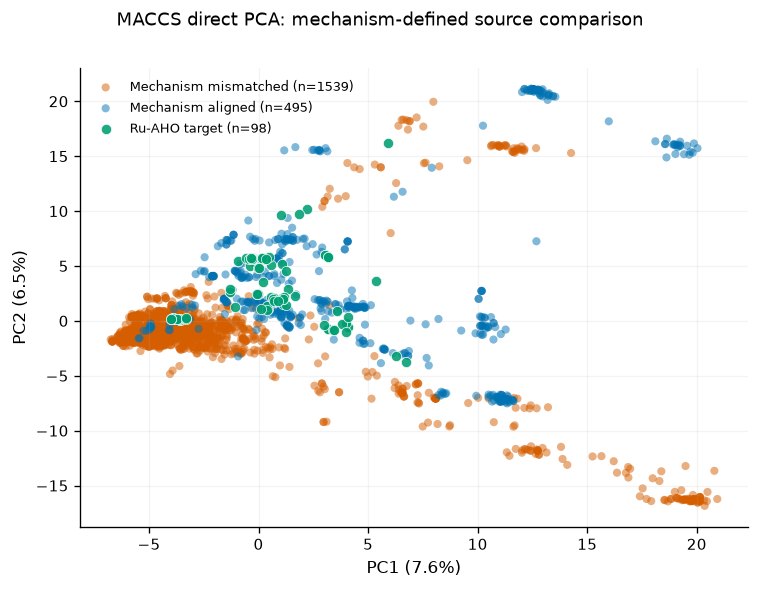

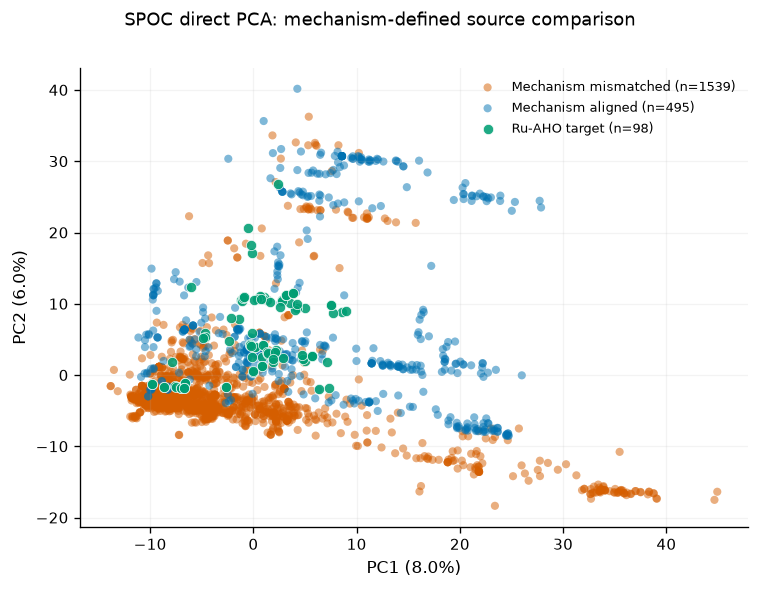

In [4]:
def save_svg(fig, path: Path):
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        facecolor="white",
    )
    ET.parse(path)


def plot_mechanism_pca(descriptor: str):
    model = PCA_MODELS[descriptor]
    transformed = model["transformed"]
    variance = model["explained_variance_ratio"]

    target = transformed["ru_aho_inner"]
    source_map = {
        "mechanism_aligned": transformed["ru_ahk_inner"],
        "mechanism_mismatched": transformed["ru_ahk_outer"],
    }

    # For the main-text comparison, overlay both source domains in one
    # common PCA panel and draw the target last for visual prominence.
    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    for rule_id in ["mechanism_mismatched", "mechanism_aligned"]:
        source = source_map[rule_id]
        ax.scatter(
            source[:, 0],
            source[:, 1],
            s=24,
            color=RULE_COLORS[rule_id],
            alpha=0.50,
            edgecolors="none",
            label=f"{RULE_LABELS[rule_id]} (n={len(source)})",
        )

    ax.scatter(
        target[:, 0],
        target[:, 1],
        s=38,
        marker="o",
        color=TARGET_COLOR,
        alpha=0.88,
        edgecolors="white",
        linewidths=0.45,
        label=f"Ru-AHO target (n={len(target)})",
        zorder=5,
    )
    ax.set_xlabel(f"PC1 ({variance[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({variance[1] * 100:.1f}%)")
    ax.grid(alpha=0.15)
    ax.legend(frameon=False, loc="best")
    fig.suptitle(
        f"{DESCRIPTOR_LABELS[descriptor]} direct PCA: "
        "mechanism-defined source comparison",
        y=1.01,
    )
    fig.tight_layout()

    output_path = (
        FIG_DIR
        / f"{descriptor}_mechanism_defined_source_target_pca.svg"
    )
    save_svg(fig, output_path)
    plt.show()
    return output_path


MECHANISM_PCA_PATHS = {
    descriptor: plot_mechanism_pca(descriptor)
    for descriptor in ["maccs", "spoc"]
}

## 4. Direct source-to-target distance metrics

The similarity-selected and distribution-matched sources vary across target
folds. Metrics are therefore calculated separately for each fold using its
current target-training subset and exact selected source rows, then summarized
as mean ± standard deviation.

The quantitative space exactly matches the RBF-MMD source-selection space:
fold-local pooled median imputation and standardization of the complete
reaction representation. Lower values indicate closer source and target
distributions. RBF-MMD is the prespecified matching criterion; the remaining
metrics are cross-metric sensitivities.

In [5]:
TARGET_SPLITS = list(
    KFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    ).split(np.zeros(len(DATASETS["ru_aho_inner"])))
)


def deterministic_subsample(X, max_points, seed):
    X = np.asarray(X, dtype=np.float32)
    if len(X) <= max_points:
        return X
    rng = np.random.default_rng(seed)
    indices = rng.choice(
        len(X),
        size=max_points,
        replace=False,
    )
    return X[np.sort(indices)]


def shared_rbf_gamma(
    reference,
    max_points=RBF_MMD_GAMMA_MAX_POINTS,
):
    reference = deterministic_subsample(
        reference,
        max_points=max_points,
        seed=RANDOM_STATE,
    )
    distances = pairwise_distances(
        reference,
        metric="euclidean",
    )
    values = distances[
        np.triu_indices_from(distances, k=1)
    ]
    values = values[
        np.isfinite(values)
        & (values > 0)
    ]
    if len(values) == 0:
        return 1.0
    median_distance = float(np.median(values))
    return 1.0 / (
        2.0 * median_distance**2
        + 1e-12
    )


def rbf_mmd(X, Y, gamma):
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    value2 = float(
        Kxx.mean()
        + Kyy.mean()
        - 2.0 * Kxy.mean()
    )
    return float(np.sqrt(max(value2, 0.0)))


def multivariate_energy_distance(X, Y):
    X = deterministic_subsample(
        X,
        MAX_DISTANCE_POINTS,
        RANDOM_STATE + 3,
    )
    Y = deterministic_subsample(
        Y,
        MAX_DISTANCE_POINTS,
        RANDOM_STATE + 4,
    )
    cross = pairwise_distances(X, Y).mean()
    within_x = pairwise_distances(X, X).mean()
    within_y = pairwise_distances(Y, Y).mean()
    value = 2.0 * cross - within_x - within_y
    return float(max(value, 0.0))


def sliced_wasserstein_distance(X, Y, seed):
    X = deterministic_subsample(
        X,
        MAX_DISTANCE_POINTS,
        seed + 1,
    )
    Y = deterministic_subsample(
        Y,
        MAX_DISTANCE_POINTS,
        seed + 2,
    )

    rng = np.random.default_rng(seed)
    directions = rng.normal(
        size=(SLICED_PROJECTIONS, X.shape[1])
    )
    directions /= (
        np.linalg.norm(
            directions,
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    projected_x = X @ directions.T
    projected_y = Y @ directions.T

    quantiles = np.linspace(
        0.0,
        1.0,
        SLICED_QUANTILES,
    )
    qx = np.quantile(
        projected_x,
        quantiles,
        axis=0,
    )
    qy = np.quantile(
        projected_y,
        quantiles,
        axis=0,
    )
    return float(np.mean(np.abs(qx - qy)))


def median_knn_distance(reference, query, k=KNN_K):
    k_eff = max(1, min(int(k), len(reference)))
    model = NearestNeighbors(
        n_neighbors=k_eff,
        metric="euclidean",
    ).fit(reference)
    distances, _ = model.kneighbors(query)
    return float(
        np.median(distances.mean(axis=1))
    )


def symmetric_knn_distance(X, Y):
    return 0.5 * (
        median_knn_distance(X, Y)
        + median_knn_distance(Y, X)
    )


def fold_standardized_space(
    descriptor,
    target_train_indices,
):
    all_source = FEATURES[descriptor][
        "all_ru_ahk"
    ]
    target_train = FEATURES[descriptor][
        "ru_aho_inner"
    ][target_train_indices]

    pooled = np.vstack(
        [all_source, target_train]
    )
    imputer = make_imputer()
    pooled = imputer.fit_transform(pooled)
    pooled = np.nan_to_num(
        pooled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    scaler = StandardScaler()
    pooled = scaler.fit_transform(pooled)
    pooled = np.nan_to_num(
        pooled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)

    n_all = len(all_source)
    all_scaled = pooled[:n_all]
    target_scaled = pooled[n_all:]

    transformed = {
        "all_ru_ahk": all_scaled,
        "ru_aho_inner_train": target_scaled,
    }
    for dataset_key in [
        "ru_ahk_inner",
        "ru_ahk_outer",
    ]:
        matrix = imputer.transform(
            FEATURES[descriptor][dataset_key]
        )
        matrix = np.nan_to_num(
            matrix,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        matrix = scaler.transform(matrix)
        transformed[dataset_key] = np.nan_to_num(
            matrix,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).astype(np.float32)

    gamma = shared_rbf_gamma(
        np.vstack(
            [all_scaled, target_scaled]
        )
    )
    return transformed, gamma


def source_matrix_for_fold(
    descriptor,
    rule_id,
    fold_id,
    transformed,
):
    fixed_dataset = {
        "mechanism_aligned": "ru_ahk_inner",
        "mechanism_mismatched": "ru_ahk_outer",
        "all_ru_ahk": "all_ru_ahk",
    }
    if rule_id in fixed_dataset:
        return transformed[
            fixed_dataset[rule_id]
        ]

    membership = MEMBERSHIPS[descriptor]
    selected = membership.loc[
        membership["source_rule_id"].eq(rule_id)
        & membership["fold_id"].eq(int(fold_id))
    ].copy()

    if selected.empty:
        raise ValueError(
            f"No {descriptor} membership rows for {rule_id}, fold {fold_id}."
        )
    if selected["dataset_key"].nunique() != 1:
        raise ValueError(
            f"{descriptor} {rule_id} fold {fold_id} uses multiple datasets."
        )

    dataset_key = selected[
        "dataset_key"
    ].iloc[0]
    indices = selected[
        "selected_index"
    ].to_numpy(dtype=int)
    if len(np.unique(indices)) != len(indices):
        raise ValueError(
            f"Duplicate selected rows in {descriptor} {rule_id}, fold {fold_id}."
        )
    return transformed[dataset_key][indices]


metric_rows = []
matching_qc_rows = []

for descriptor in ["maccs", "spoc"]:
    for fold_id, (
        target_train_idx,
        _,
    ) in enumerate(
        TARGET_SPLITS,
        start=1,
    ):
        transformed, gamma = (
            fold_standardized_space(
                descriptor,
                target_train_idx,
            )
        )
        target = transformed[
            "ru_aho_inner_train"
        ]
        fold_values = {}

        for rule_id in SOURCE_RULE_ORDER:
            source = source_matrix_for_fold(
                descriptor,
                rule_id,
                fold_id,
                transformed,
            )
            rbf_value = rbf_mmd(
                source,
                target,
                gamma,
            )
            fold_values[rule_id] = rbf_value
            metric_rows.append(
                {
                    "descriptor_id": descriptor,
                    "descriptor": DESCRIPTOR_LABELS[
                        descriptor
                    ],
                    "fold_id": fold_id,
                    "source_rule_id": rule_id,
                    "source_label": RULE_LABELS[
                        rule_id
                    ],
                    "n_source": len(source),
                    "n_target_train": len(target),
                    "rbf_gamma": gamma,
                    "rbf_mmd": rbf_value,
                    "energy_distance": (
                        multivariate_energy_distance(
                            source,
                            target,
                        )
                    ),
                    "sliced_wasserstein": (
                        sliced_wasserstein_distance(
                            source,
                            target,
                            seed=(
                                RANDOM_STATE
                                + 100 * fold_id
                            ),
                        )
                    ),
                    "symmetric_knn_distance": (
                        symmetric_knn_distance(
                            source,
                            target,
                        )
                    ),
                }
            )

        matched = fold_values[
            "reaction_representation_matched"
        ]
        aligned = fold_values[
            "mechanism_aligned"
        ]
        matching_qc_rows.append(
            {
                "descriptor_id": descriptor,
                "descriptor": DESCRIPTOR_LABELS[
                    descriptor
                ],
                "fold_id": fold_id,
                "reaction_representation_matched_rbf_mmd": matched,
                "mechanism_aligned_rbf_mmd": aligned,
                "matched_minus_aligned": matched - aligned,
                "matched_is_closer": bool(
                    matched <= aligned + 1e-10
                ),
            }
        )


DIRECT_METRICS_BY_FOLD = pd.DataFrame(
    metric_rows
)
DIRECT_METRICS_BY_FOLD.to_csv(
    TABLE_DIR / "direct_geometry_metrics_by_fold.csv",
    index=False,
)

RBF_MMD_MATCHING_QC = pd.DataFrame(
    matching_qc_rows
)
RBF_MMD_MATCHING_QC.to_csv(
    TABLE_DIR / "rbf_mmd_matching_qc.csv",
    index=False,
)
if not RBF_MMD_MATCHING_QC[
    "matched_is_closer"
].all():
    raise AssertionError(
        "The reaction-representation-matched source is not closer than "
        "the mechanism-aligned source under the exact RBF-MMD matching metric."
    )

summary_rows = []
for keys, group in DIRECT_METRICS_BY_FOLD.groupby(
    [
        "descriptor_id",
        "descriptor",
        "source_rule_id",
        "source_label",
    ],
    sort=False,
):
    (
        descriptor_id,
        descriptor,
        rule_id,
        rule_label,
    ) = keys
    for metric_id, metric_label in (
        METRIC_LABELS.items()
    ):
        values = group[
            metric_id
        ].to_numpy(dtype=float)
        summary_rows.append(
            {
                "descriptor_id": descriptor_id,
                "descriptor": descriptor,
                "source_rule_id": rule_id,
                "source_label": rule_label,
                "metric_id": metric_id,
                "metric_label": metric_label,
                "mean": float(np.mean(values)),
                "std": float(
                    np.std(values, ddof=1)
                ),
                "median": float(np.median(values)),
                "minimum": float(np.min(values)),
                "maximum": float(np.max(values)),
                "n_folds": len(values),
                "lower_is_closer": True,
            }
        )

DIRECT_METRICS_SUMMARY = pd.DataFrame(
    summary_rows
)
DIRECT_METRICS_SUMMARY.to_csv(
    TABLE_DIR / "direct_geometry_metrics_summary.csv",
    index=False,
)

display(RBF_MMD_MATCHING_QC.round(4))
display(
    DIRECT_METRICS_SUMMARY.loc[
        DIRECT_METRICS_SUMMARY[
            "source_rule_id"
        ].isin(MECHANISM_RULES)
    ].round(4)
)


,descriptor_id,descriptor,fold_id,reaction_representation_matched_rbf_mmd,mechanism_aligned_rbf_mmd,matched_minus_aligned,matched_is_closer
0,maccs,MACCS,1,0.3326,0.3751,-0.0425,True
1,maccs,MACCS,2,0.3319,0.3751,-0.0432,True
2,maccs,MACCS,3,0.3305,0.3745,-0.0439,True
3,maccs,MACCS,4,0.3318,0.3719,-0.0401,True
4,maccs,MACCS,5,0.3349,0.3763,-0.0415,True
5,spoc,SPOC,1,0.3133,0.3578,-0.0445,True
6,spoc,SPOC,2,0.3105,0.3564,-0.0459,True
7,spoc,SPOC,3,0.3105,0.3561,-0.0455,True
8,spoc,SPOC,4,0.3143,0.3573,-0.0430,True
9,spoc,SPOC,5,0.3144,0.3584,-0.0440,True


,descriptor_id,descriptor,source_rule_id,source_label,metric_id,metric_label,mean,std,median,minimum,maximum,n_folds,lower_is_closer
0,maccs,MACCS,mechanism_aligned,Mechanism aligned,rbf_mmd,RBF-MMD,0.3746,0.0017,0.3751,0.3719,0.3763,5,True
1,maccs,MACCS,mechanism_aligned,Mechanism aligned,energy_distance,Energy distance,8.4310,0.0512,8.4568,8.3472,8.4672,5,True
2,maccs,MACCS,mechanism_aligned,Mechanism aligned,sliced_wasserstein,Sliced Wasserstein,0.5461,0.0325,0.5337,0.5167,0.5881,5,True
3,maccs,MACCS,mechanism_aligned,Mechanism aligned,symmetric_knn_distance,Symmetric kNN distance,29.1868,1.2087,28.5996,28.0401,31.0659,5,True
4,maccs,MACCS,mechanism_mismatched,Mechanism mismatched,rbf_mmd,RBF-MMD,0.4564,0.0017,0.4568,0.4545,0.4586,5,True
5,maccs,MACCS,mechanism_mismatched,Mechanism mismatched,energy_distance,Energy distance,11.7190,0.1316,11.7029,11.5428,11.9086,5,True
6,maccs,MACCS,mechanism_mismatched,Mechanism mismatched,sliced_wasserstein,Sliced Wasserstein,0.6225,0.0268,0.6145,0.5879,0.6506,5,True
7,maccs,MACCS,mechanism_mismatched,Mechanism mismatched,symmetric_knn_distance,Symmetric kNN distance,28.5426,0.4184,28.6275,27.9457,28.9981,5,True
24,spoc,SPOC,mechanism_aligned,Mechanism aligned,rbf_mmd,RBF-MMD,0.3572,0.0010,0.3573,0.3561,0.3584,5,True
25,spoc,SPOC,mechanism_aligned,Mechanism aligned,energy_distance,Energy distance,12.3324,0.0779,12.3225,12.2594,12.4614,5,True


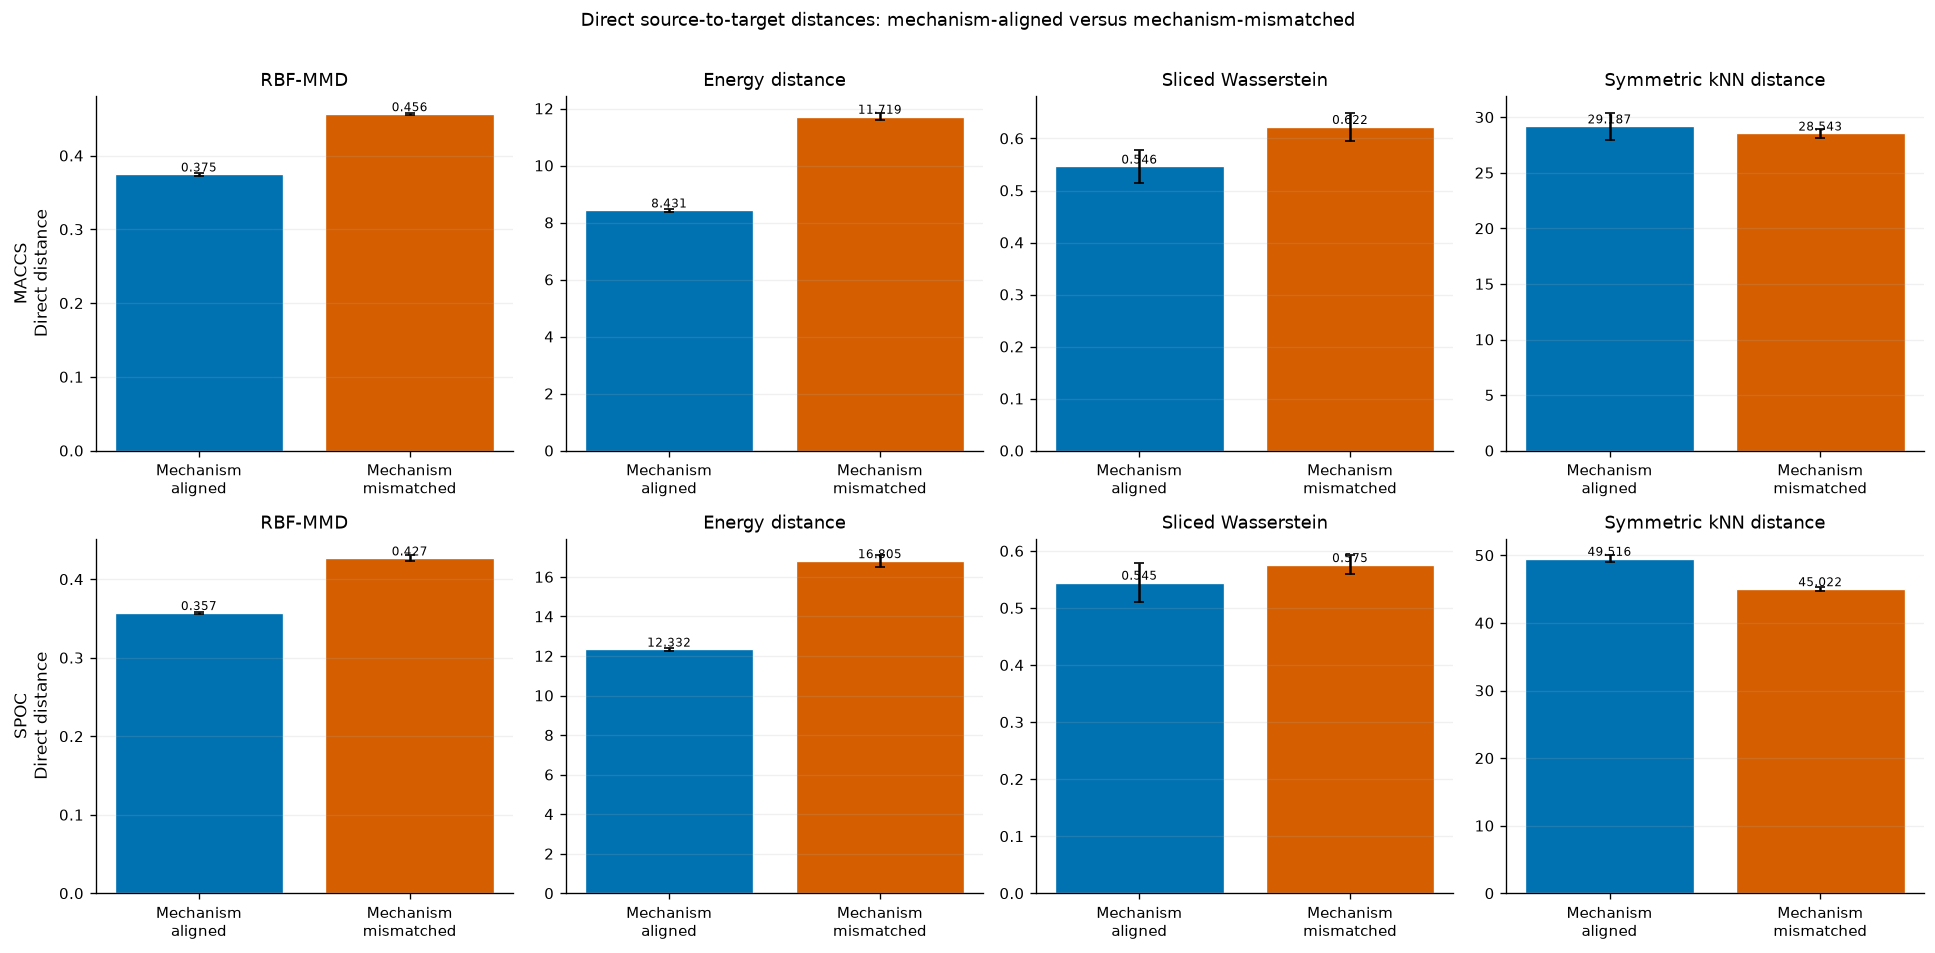

In [6]:
def plot_metric_grid(rule_ids, title, filename):
    fig, axes = plt.subplots(
        2,
        len(METRIC_LABELS),
        figsize=(16.2, 7.8),
        squeeze=False,
    )

    horizontal = len(rule_ids) > 3

    for row_index, descriptor in enumerate(
        ["maccs", "spoc"]
    ):
        for column_index, (
            metric_id,
            metric_label,
        ) in enumerate(METRIC_LABELS.items()):
            ax = axes[row_index, column_index]
            subset = DIRECT_METRICS_SUMMARY.loc[
                DIRECT_METRICS_SUMMARY[
                    "descriptor_id"
                ].eq(descriptor)
                & DIRECT_METRICS_SUMMARY[
                    "metric_id"
                ].eq(metric_id)
                & DIRECT_METRICS_SUMMARY[
                    "source_rule_id"
                ].isin(rule_ids)
            ].copy()

            subset["order"] = subset[
                "source_rule_id"
            ].map(
                {
                    rule: index
                    for index, rule in enumerate(rule_ids)
                }
            )
            subset = subset.sort_values("order")
            colors = [
                RULE_COLORS[rule]
                for rule in subset[
                    "source_rule_id"
                ]
            ]

            if horizontal:
                y = np.arange(len(subset))
                bars = ax.barh(
                    y,
                    subset["mean"],
                    xerr=subset["std"],
                    color=colors,
                    edgecolor="white",
                    linewidth=0.8,
                    capsize=3,
                )
                ax.set_yticks(y)
                ax.set_yticklabels(
                    [
                        RULE_LABELS[rule]
                        for rule in subset[
                            "source_rule_id"
                        ]
                    ],
                    fontsize=8,
                )
                ax.invert_yaxis()
                ax.grid(axis="x", alpha=0.18)
                for bar, value in zip(
                    bars,
                    subset["mean"],
                ):
                    ax.text(
                        bar.get_width(),
                        bar.get_y()
                        + bar.get_height() / 2,
                        f" {value:.3f}",
                        ha="left",
                        va="center",
                        fontsize=7,
                    )
            else:
                x = np.arange(len(subset))
                bars = ax.bar(
                    x,
                    subset["mean"],
                    yerr=subset["std"],
                    color=colors,
                    edgecolor="white",
                    linewidth=0.8,
                    capsize=3,
                )
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [
                        RULE_LABELS[rule].replace(
                            " ",
                            "\n",
                        )
                        for rule in subset[
                            "source_rule_id"
                        ]
                    ],
                )
                ax.grid(axis="y", alpha=0.18)
                for bar, value in zip(
                    bars,
                    subset["mean"],
                ):
                    ax.text(
                        bar.get_x()
                        + bar.get_width() / 2,
                        bar.get_height(),
                        f"{value:.3f}",
                        ha="center",
                        va="bottom",
                        fontsize=7,
                    )

            ax.set_title(metric_label)
            if column_index == 0:
                ax.set_ylabel(
                    f"{DESCRIPTOR_LABELS[descriptor]}\nDirect distance"
                )

    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    output_path = FIG_DIR / filename
    save_svg(fig, output_path)
    plt.show()
    return output_path


MECHANISM_METRIC_FIGURE = plot_metric_grid(
    MECHANISM_RULES,
    (
        "Direct source-to-target distances: "
        "mechanism-aligned versus mechanism-mismatched"
    ),
    "mechanism_defined_direct_distance_metrics.svg",
)


## 5. Extend the same PCA analysis to the remaining source rules

For fold-local controls, each PCA panel displays the union of selected Ru-AHK
rows across the five target folds. Point area reflects the fraction of folds in
which each row was selected.

The reaction-representation-matched panel therefore visualizes the exact
`reaction_repr_rbf_mmd_minimized` memberships used in notebooks 1.3 and 1.4.
`All Ru-AHK` is shown at its natural size.

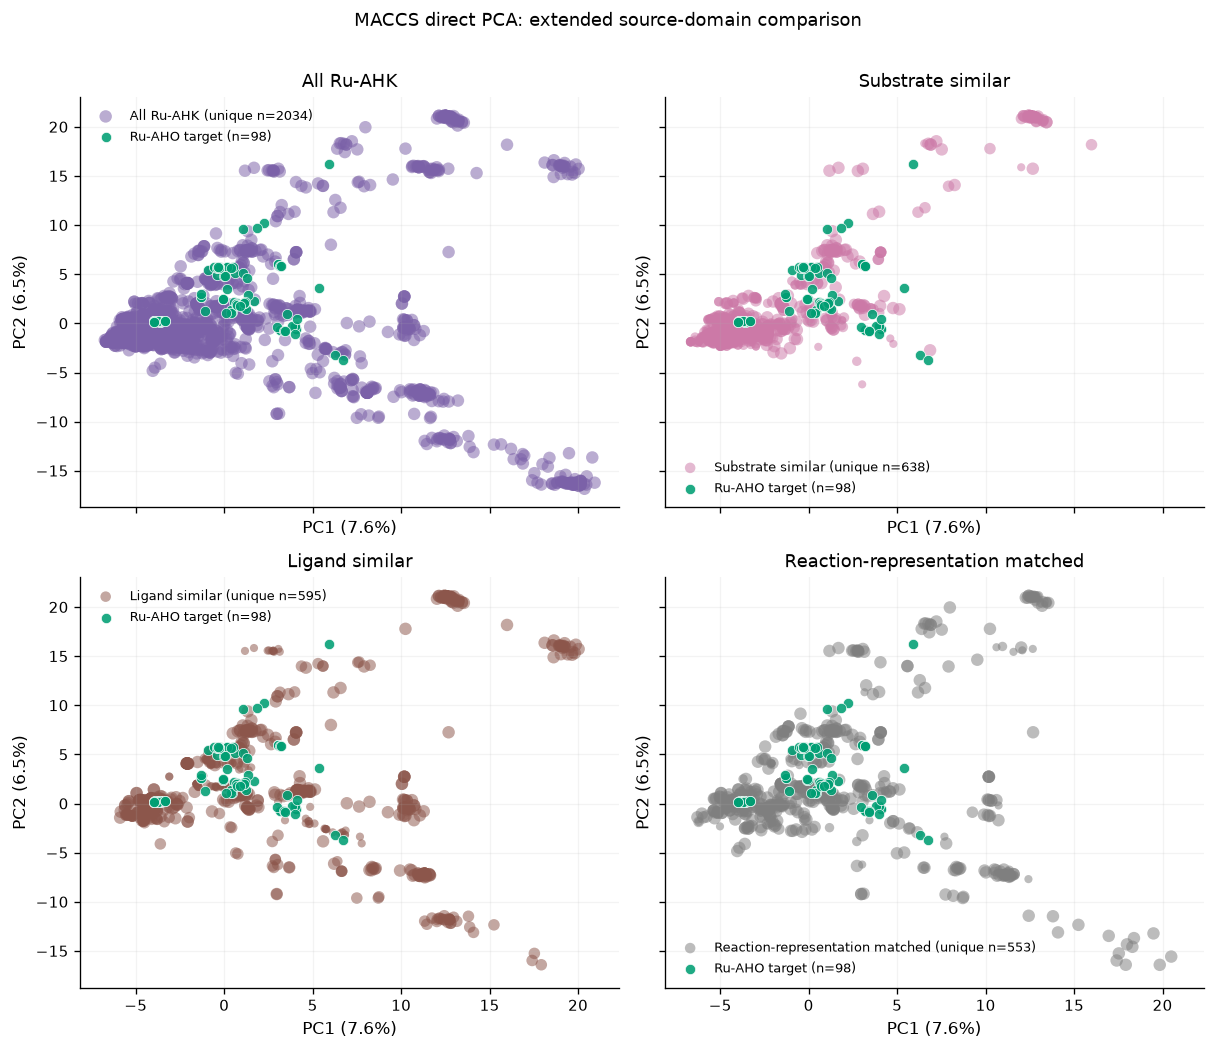

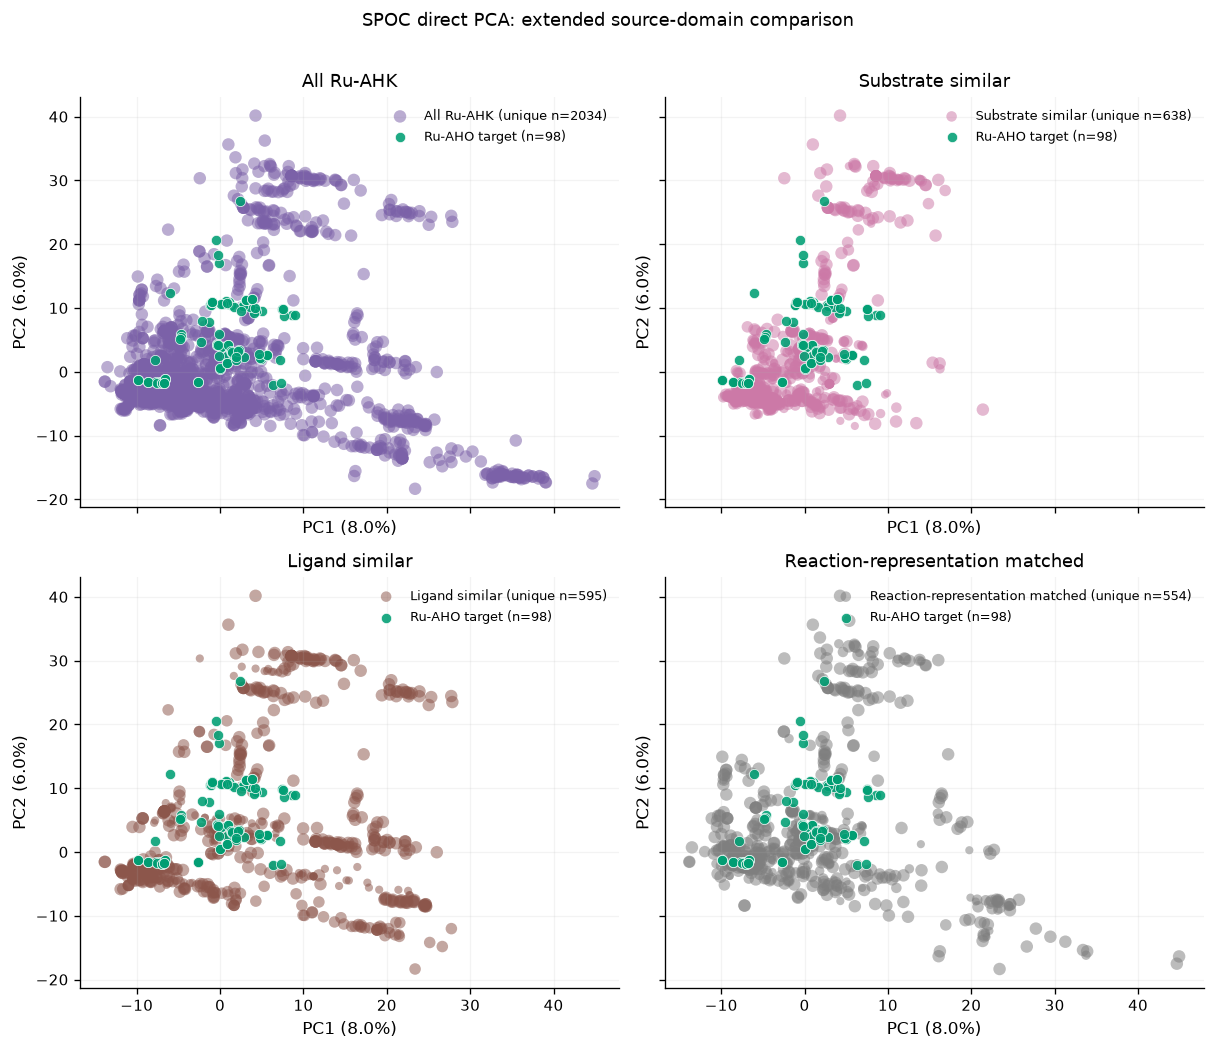

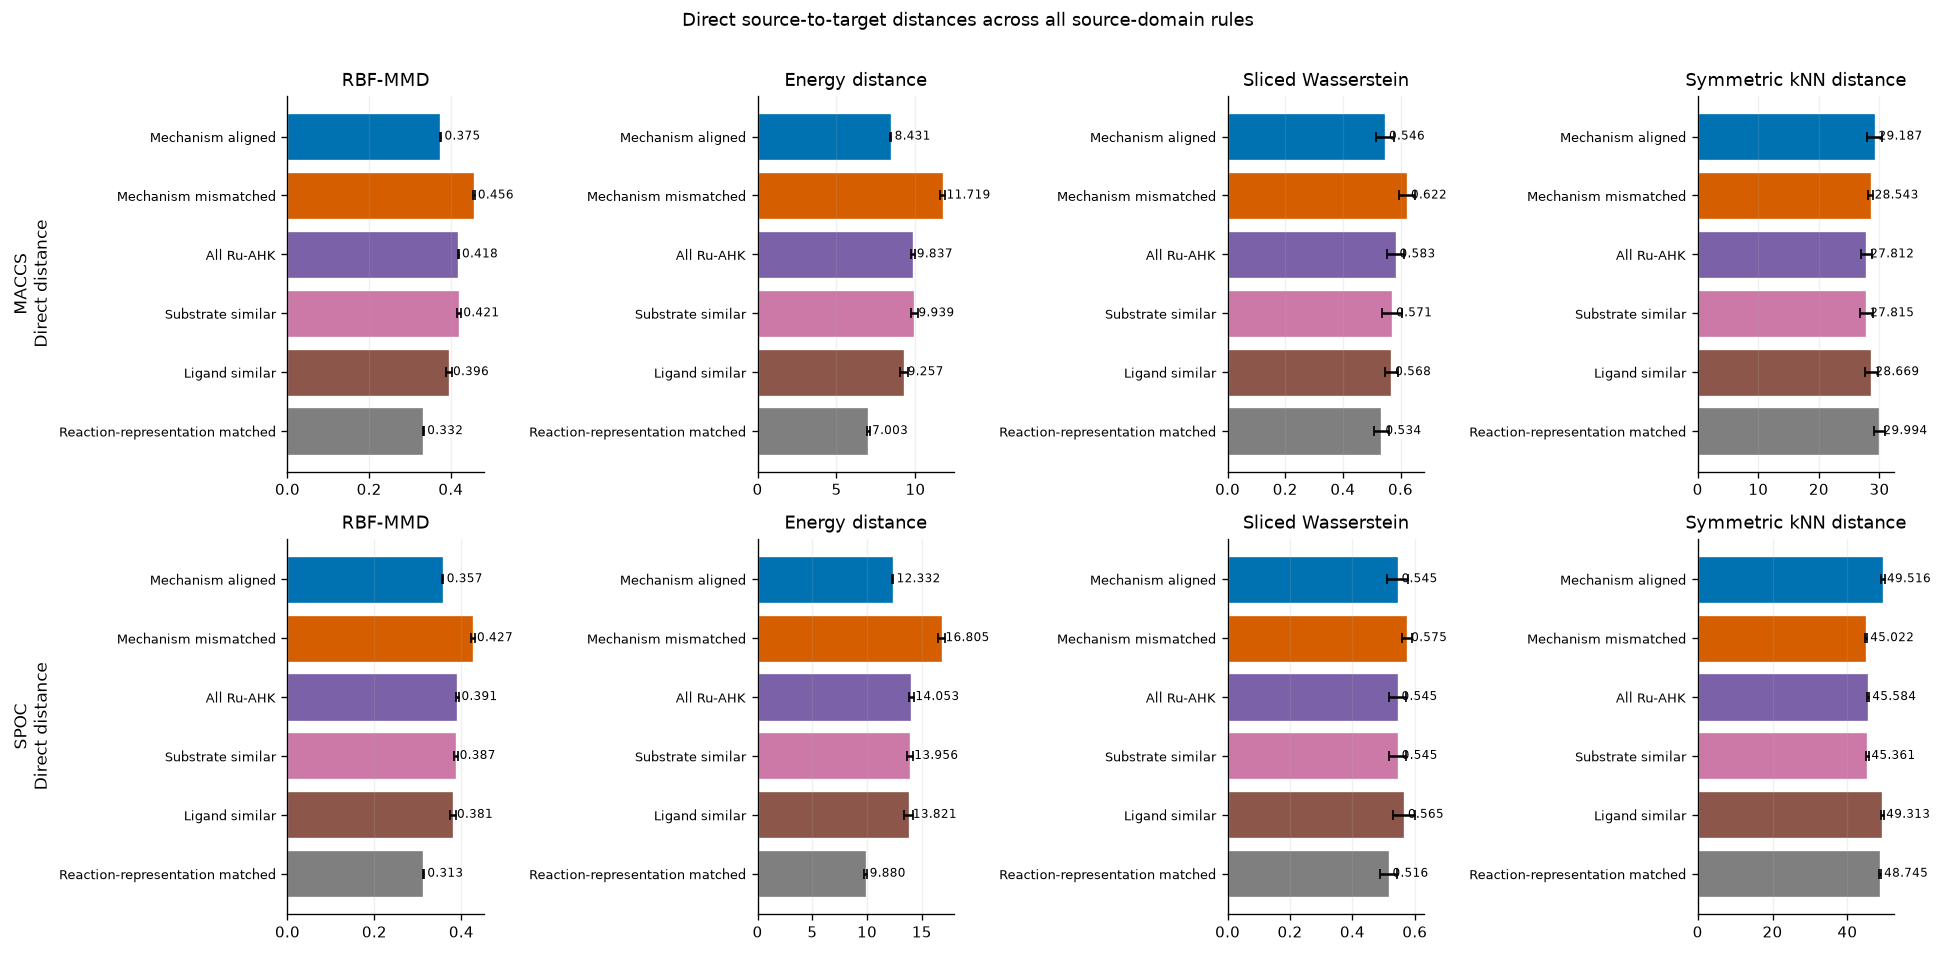

In [7]:
def source_union_for_plot(descriptor, rule_id):
    transformed = PCA_MODELS[descriptor]["transformed"]

    if rule_id == "all_ru_ahk":
        matrix = transformed["all_ru_ahk"]
        frequency = np.ones(len(matrix), dtype=float)
        return matrix, frequency

    membership = MEMBERSHIPS[descriptor]
    subset = membership.loc[
        membership["source_rule_id"].eq(rule_id)
    ].copy()
    if subset.empty:
        raise ValueError(
            f"No membership rows for {descriptor} {rule_id}."
        )
    if subset["dataset_key"].nunique() != 1:
        raise ValueError(
            f"{descriptor} {rule_id} uses multiple source datasets."
        )

    dataset_key = subset["dataset_key"].iloc[0]
    frequencies = (
        subset.groupby("selected_index")["fold_id"]
        .nunique()
        .div(N_FOLDS)
        .sort_index()
    )
    indices = frequencies.index.to_numpy(dtype=int)
    return (
        transformed[dataset_key][indices],
        frequencies.to_numpy(dtype=float),
    )


def plot_extended_source_pca(descriptor):
    model = PCA_MODELS[descriptor]
    target = model["transformed"]["ru_aho_inner"]
    variance = model["explained_variance_ratio"]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10.2, 8.6),
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    coordinate_rows = []

    for ax, rule_id in zip(axes, EXTENDED_RULES):
        source, frequency = source_union_for_plot(
            descriptor,
            rule_id,
        )
        sizes = 16 + 40 * frequency

        ax.scatter(
            source[:, 0],
            source[:, 1],
            s=sizes,
            color=RULE_COLORS[rule_id],
            alpha=0.52,
            edgecolors="none",
            label=(
                f"{RULE_LABELS[rule_id]} "
                f"(unique n={len(source)})"
            ),
        )
        ax.scatter(
            target[:, 0],
            target[:, 1],
            s=38,
            marker="o",
            color=TARGET_COLOR,
            alpha=0.88,
            edgecolors="white",
            linewidths=0.45,
            label=f"Ru-AHO target (n={len(target)})",
            zorder=5,
        )
        ax.set_title(RULE_LABELS[rule_id])
        ax.set_xlabel(f"PC1 ({variance[0] * 100:.1f}%)")
        ax.set_ylabel(f"PC2 ({variance[1] * 100:.1f}%)")
        ax.grid(alpha=0.15)
        ax.legend(frameon=False, loc="best")

        for row_index, (point, freq) in enumerate(
            zip(source[:, :2], frequency)
        ):
            coordinate_rows.append(
                {
                    "descriptor_id": descriptor,
                    "source_rule_id": rule_id,
                    "point_index": row_index,
                    "PC1": float(point[0]),
                    "PC2": float(point[1]),
                    "selection_frequency": float(freq),
                }
            )

    fig.suptitle(
        f"{DESCRIPTOR_LABELS[descriptor]} direct PCA: "
        "extended source-domain comparison",
        y=1.01,
    )
    fig.tight_layout()
    output_path = (
        FIG_DIR
        / f"{descriptor}_extended_source_target_pca.svg"
    )
    save_svg(fig, output_path)
    plt.show()

    pd.DataFrame(coordinate_rows).to_csv(
        TABLE_DIR
        / f"{descriptor}_extended_source_pca_coordinates.csv",
        index=False,
    )
    return output_path


EXTENDED_PCA_PATHS = {
    descriptor: plot_extended_source_pca(descriptor)
    for descriptor in ["maccs", "spoc"]
}

ALL_SOURCE_METRIC_FIGURE = plot_metric_grid(
    SOURCE_RULE_ORDER,
    "Direct source-to-target distances across all source-domain rules",
    "all_source_rules_direct_distance_metrics.svg",
)

## 6. Representation-level interpretation and output validation

The two-dimensional PCA panels are descriptive projections. The four direct
metrics retain substantially more reaction-feature information and are used to
support the source-to-target proximity comparison.

In [8]:
interpretation_rows = []

for descriptor in ["maccs", "spoc"]:
    subset = DIRECT_METRICS_SUMMARY.loc[
        DIRECT_METRICS_SUMMARY["descriptor_id"].eq(descriptor)
        & DIRECT_METRICS_SUMMARY["source_rule_id"].isin(MECHANISM_RULES)
    ].copy()

    pivot = subset.pivot(
        index="metric_id",
        columns="source_rule_id",
        values="mean",
    )
    pivot["aligned_is_closer"] = (
        pivot["mechanism_aligned"]
        < pivot["mechanism_mismatched"]
    )

    interpretation_rows.append(
        {
            "descriptor": DESCRIPTOR_LABELS[descriptor],
            "metrics_favoring_mechanism_aligned": int(
                pivot["aligned_is_closer"].sum()
            ),
            "total_metrics": len(pivot),
            "all_metrics_favor_mechanism_aligned": bool(
                pivot["aligned_is_closer"].all()
            ),
        }
    )

INTERPRETATION = pd.DataFrame(interpretation_rows)
INTERPRETATION.to_csv(
    TABLE_DIR / "mechanism_geometry_interpretation.csv",
    index=False,
)
display(INTERPRETATION)

expected_figures = [
    *MECHANISM_PCA_PATHS.values(),
    MECHANISM_METRIC_FIGURE,
    *EXTENDED_PCA_PATHS.values(),
    ALL_SOURCE_METRIC_FIGURE,
]

for figure_path in expected_figures:
    if not figure_path.exists():
        raise FileNotFoundError(figure_path)
    ET.parse(figure_path)

if DIRECT_METRICS_BY_FOLD.replace(
    [np.inf, -np.inf],
    np.nan,
).isna().any().any():
    raise ValueError("Direct geometry metrics contain missing values.")

if not RBF_MMD_MATCHING_QC["matched_is_closer"].all():
    raise AssertionError("RBF-MMD matching QC failed.")

print("All 2.1 figures and tables passed validation.")
print(
    "Interpretation boundary: PCA overlap and direct descriptor proximity "
    "are descriptive evidence; they do not by themselves establish the "
    "chemical origin of transferability."
)

,descriptor,metrics_favoring_mechanism_aligned,total_metrics,all_metrics_favor_mechanism_aligned
0,MACCS,3,4,False
1,SPOC,3,4,False


All 2.1 figures and tables passed validation.
Interpretation boundary: PCA overlap and direct descriptor proximity are descriptive evidence; they do not by themselves establish the chemical origin of transferability.
